# Simulated Actions Statistical Analysis

This notebook performs a comprehensive statistical analysis of the simulated actions data from episode 3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [2]:
# Load the simulated actions data
actions_df = pd.read_csv('data/episode-100/monitor/simulated_actions.csv')

# Display basic information about the dataset
print(f"Total number of actions: {len(actions_df)}")
print("\nFirst few rows of the dataset:")
actions_df.head()

Total number of actions: 61054

First few rows of the dataset:


,flow_livroom,flow_kitchen,flow_bed1,flow_bed2,flow_bed3,water_temperature
0,0.0,0.0,0.000000,0.0,0.0,25.0
1,0.0,0.0,0.026982,0.0,0.0,25.0
2,0.0,0.0,0.026982,0.0,0.0,25.0
3,0.0,0.0,0.026982,0.0,0.0,25.0
4,0.0,0.0,0.026982,0.0,0.0,25.0


In [3]:
# Display basic statistics for each action column
print("Basic Statistics for each action:")
actions_df.describe()

Basic Statistics for each action:


,flow_livroom,flow_kitchen,flow_bed1,flow_bed2,flow_bed3,water_temperature
count,61054.000000,61054.000000,61054.000000,61054.000000,61054.000000,61054.000000
mean,0.015781,0.023766,0.015031,0.026093,0.015686,30.228259
std,0.017594,0.023899,0.013403,0.025960,0.021335,5.968222
min,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000
50%,0.000000,0.000000,0.026982,0.051920,0.000000,27.883508
75%,0.035397,0.047799,0.026982,0.051920,0.044704,34.294554
max,0.035397,0.047799,0.026982,0.051920,0.044704,45.000000


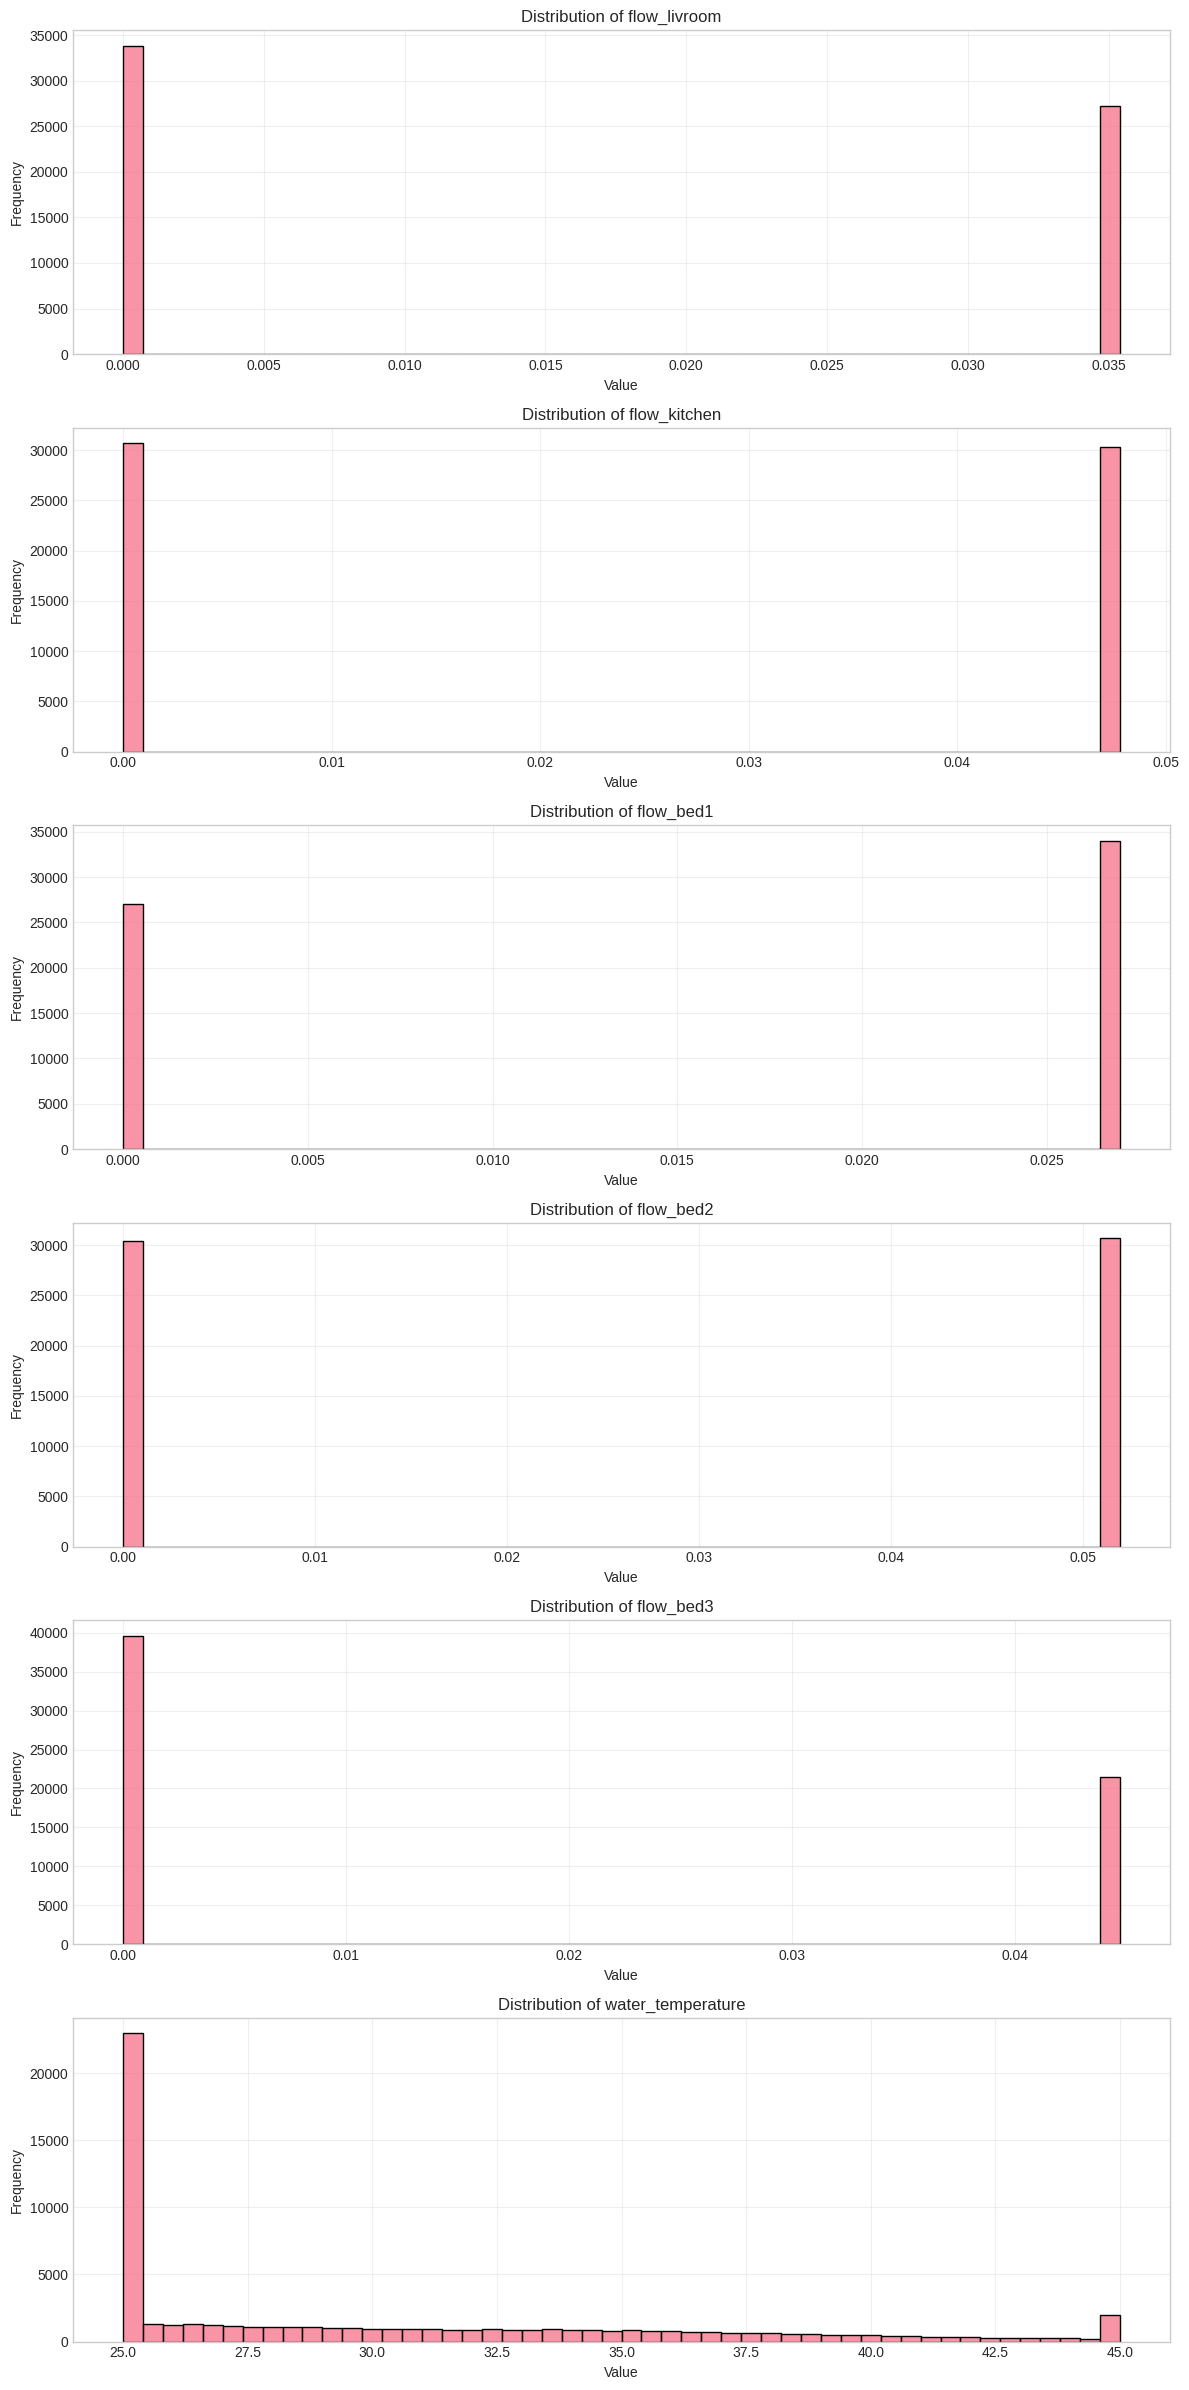

In [4]:
# Create histograms for each action
n_cols = len(actions_df.columns)
fig, axes = plt.subplots(n_cols, 1, figsize=(12, 4*n_cols))

for i, col in enumerate(actions_df.columns):
    sns.histplot(data=actions_df, x=col, ax=axes[i], bins=50)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

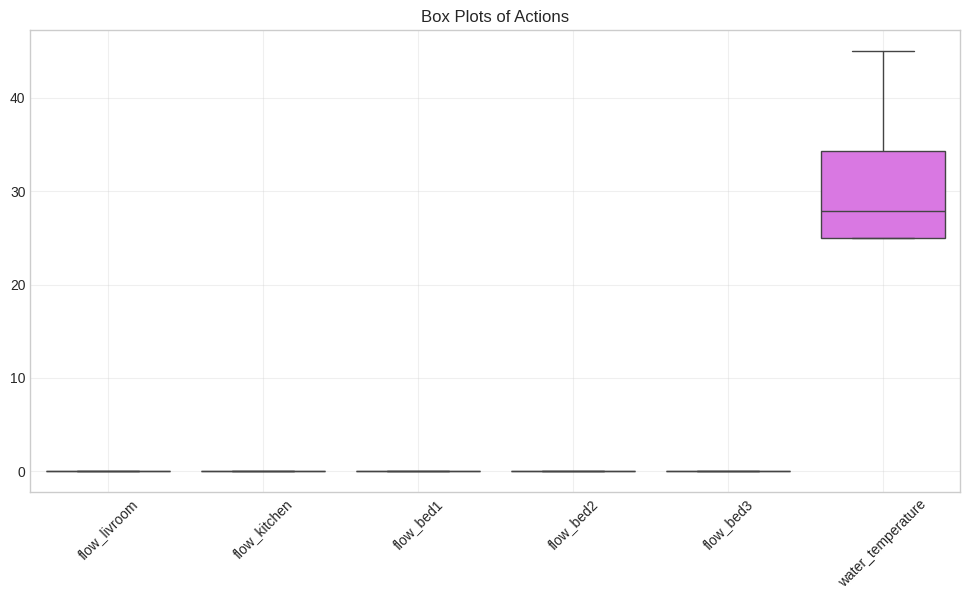

In [5]:
# Create box plots for each action
plt.figure(figsize=(12, 6))
sns.boxplot(data=actions_df)
plt.title('Box Plots of Actions')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

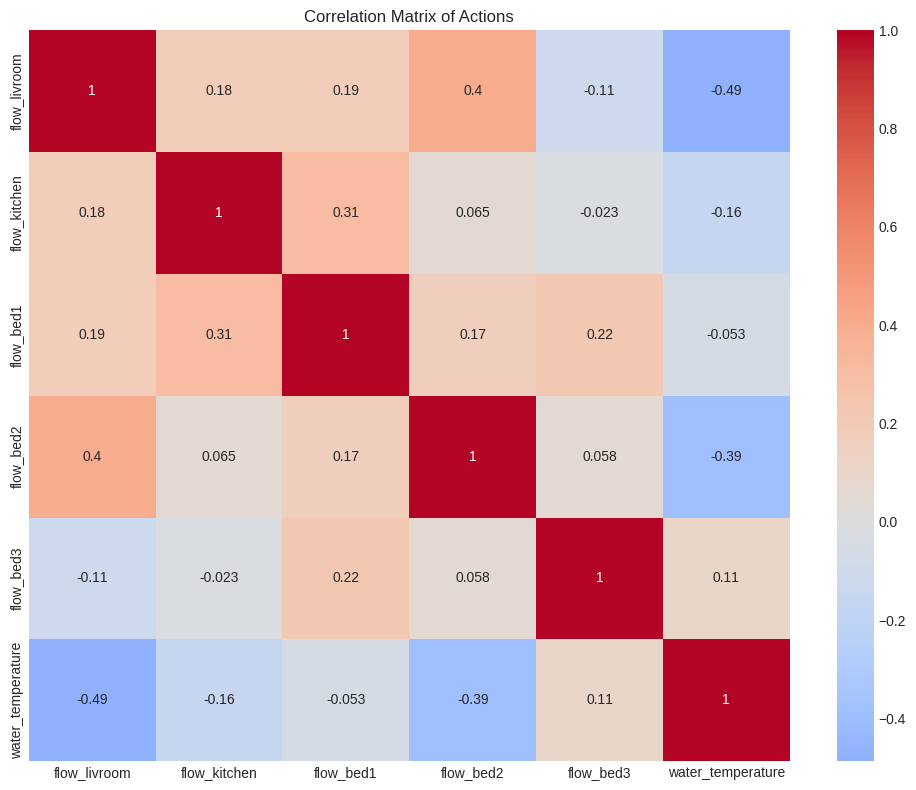

In [6]:
# Calculate correlation matrix
correlation_matrix = actions_df.corr()

# Create a heatmap of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Actions')
plt.tight_layout()
plt.show()

In [8]:
# Calculate and display additional statistics for each action
print("Additional Statistics for each action:")
for col in actions_df.columns:
    print(f"\n{col}:")
    print(f"Median: {actions_df[col].median():.2f}")
    print(f"Mode: {actions_df[col].mode().values[0]:.2f}")
    print(f"Standard deviation: {actions_df[col].std():.2f}")
    print(f"Skewness: {actions_df[col].skew():.2f}")
    print(f"Kurtosis: {actions_df[col].kurtosis():.2f}")

Additional Statistics for each action:

flow_livroom:
Median: 0.00
Mode: 0.00
Standard deviation: 0.02
Skewness: 0.00
Kurtosis: -2.00

flow_kitchen:
Median: 0.00
Mode: 0.00
Standard deviation: 0.02
Skewness: 0.01
Kurtosis: -2.00

flow_bed1:
Median: 0.00
Mode: 0.00
Standard deviation: 0.01
Skewness: 0.00
Kurtosis: -2.00

flow_bed2:
Median: 0.05
Mode: 0.05
Standard deviation: 0.03
Skewness: -0.00
Kurtosis: -2.00

flow_bed3:
Median: 0.04
Mode: 0.04
Standard deviation: 0.02
Skewness: -0.02
Kurtosis: -2.00

water_temperature:
Median: 34.96
Mode: 25.00
Standard deviation: 5.77
Skewness: 0.01
Kurtosis: -1.20


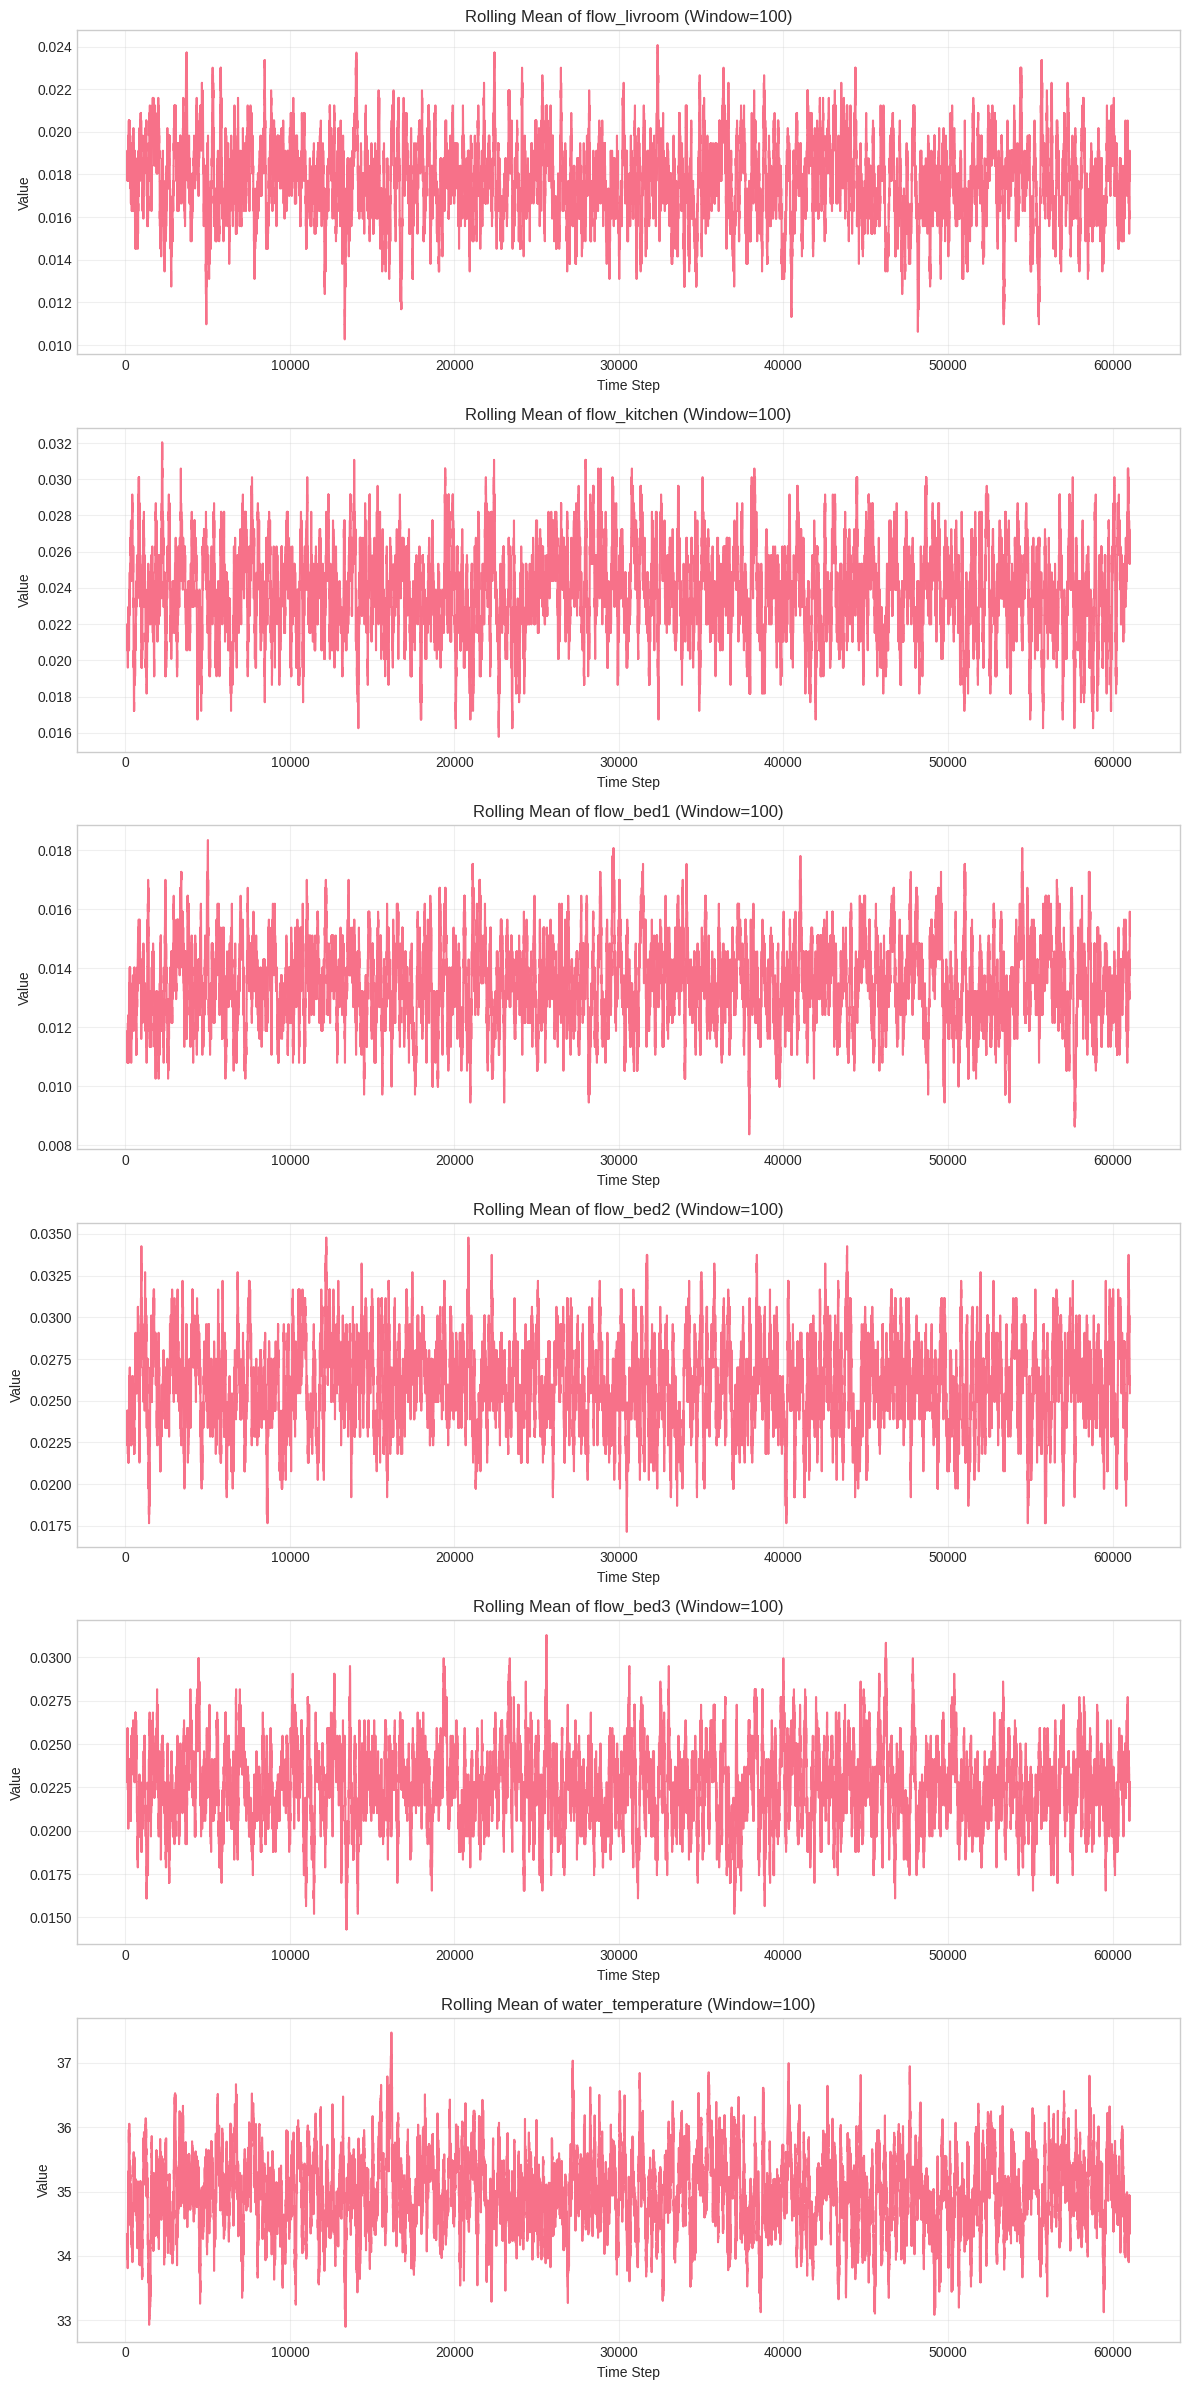

In [9]:
# Create rolling mean plots for each action
n_cols = len(actions_df.columns)
fig, axes = plt.subplots(n_cols, 1, figsize=(12, 4*n_cols))

for i, col in enumerate(actions_df.columns):
    actions_df[f'{col}_rolling_mean'] = actions_df[col].rolling(window=100).mean()
    axes[i].plot(actions_df[f'{col}_rolling_mean'])
    axes[i].set_title(f'Rolling Mean of {col} (Window=100)')
    axes[i].set_xlabel('Time Step')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary of Analysis

This analysis provides insights into the simulated actions data:

1. Basic statistics for each action (mean, median, standard deviation)
2. Distribution visualization through histograms and box plots
3. Correlation analysis between different actions
4. Trend analysis using rolling means
5. Additional statistical measures (skewness, kurtosis)

The visualizations and statistics help understand the distribution of actions and identify any patterns or relationships between different actions.